In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## War Economic & Livelihood Impact Dataset



## Description

The War Economic & Livelihood Impact Dataset provides a comprehensive overview of how armed conflicts affect economic stability, employment, income levels, and household livelihoods across affected regions.

This dataset captures the multidimensional consequences of war, including disruptions to local economies, inflation trends, unemployment rates, infrastructure damage, displacement of populations, and changes in access to essential services such as healthcare, education, and food supply.

It enables analysis of:

📉 Economic contraction and GDP changes

💼 Employment and income loss patterns

🏠 Household livelihood disruptions

🚜 Agricultural and industrial production decline

📊 Poverty rate fluctuations

🚶 Migration and displacement impacts

🏥 Access to public services during conflict

The dataset supports policymakers, researchers, economists, humanitarian organizations, and data scientists in understanding the short-term and long-term socioeconomic consequences of war.

It can be used for:

Conflict impact modeling

Economic resilience assessment

Poverty and livelihood forecasting

Policy evaluation and recovery planning

Machine learning–based risk prediction

## Import dataset

In [5]:
df = pd.read_csv("/kaggle/input/datasets/likithagedipudi/war-economic-and-livelihood-impact-dataset/war_economic_impact_dataset.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/likithagedipudi/war-economic-and-livelihood-impact-dataset/war_economic_impact_dataset.csv'

In [4]:
df.head()

NameError: name 'df' is not defined

In [4]:
df.tail()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,...,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
99995,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,4.76,6.39,1.64,...,17.59,15.01,253739029093,962895329018,24.29,38.53,Dominant,"currency, water, weapons",0.16,Yes
99996,Israel-Iran War,Interstate War,Middle East,2025,2026,Ongoing,Iran,6.31,9.18,2.88,...,29.05,40.53,442499418502,812364353669,23.63,52.81,Low,"weapons, currency",341.19,No
99997,Israel-Iran War,Interstate War,Middle East,2025,2026,Ongoing,Iran,9.21,24.93,15.71,...,44.44,88.01,80743472895,192543974304,28.69,60.65,Low,"food, weapons, fuel",139.88,Yes
99998,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),7.67,13.25,5.58,...,17.16,12.25,310021533648,1123347785558,22.96,47.43,Dominant,"water, medicine, weapons",18.20,Yes
99999,Tigray Conflict,Civil War,Africa,2020,2022,Resolved,Ethiopia,5.70,16.04,10.34,...,96.06,128.06,149842127082,255216818919,25.48,44.35,High,"currency, medicine",5.59,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   Conflict_Name                            100000 non-null  object 
 1   Conflict_Type                            100000 non-null  object 
 2   Region                                   100000 non-null  object 
 3   Start_Year                               100000 non-null  int64  
 4   End_Year                                 100000 non-null  int64  
 5   Status                                   100000 non-null  object 
 6   Primary_Country                          100000 non-null  object 
 7   Pre_War_Unemployment_%                   100000 non-null  float64
 8   During_War_Unemployment_%                100000 non-null  float64
 9   Unemployment_Spike_Percentage_Points     100000 non-null  float64
 10  Most_Affected_Sector             

In [6]:
df.describe()

,Start_Year,End_Year,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Currency_Black_Market_Rate_Gap_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000
mean,1999.401340,2009.039940,9.017027,22.625199,13.608182,17.686763,17.518820,29.077186,14.553542,20.351211,1.597617e+05,-31.614770,69.945965,87.580570,2.507148e+11,6.895004e+11,25.002639,51.783920,126.181130
std,29.957153,30.552183,3.458406,13.818295,11.960175,15.678211,7.217439,13.000781,7.487060,9.790643,9.355617e+05,18.120243,35.045196,55.632842,1.436970e+11,4.471766e+11,8.648263,21.266786,156.324982
min,1939.000000,1945.000000,3.000000,3.360000,0.320000,0.360000,5.000000,5.400000,1.840000,3.100000,1.000000e+00,-85.000000,0.030000,0.030000,1.001111e+09,1.617224e+09,10.000000,12.140000,0.000000
25%,1996.000000,2011.000000,6.030000,12.780000,5.330000,6.860000,11.260000,20.030000,9.270000,13.490000,5.710750e+03,-42.210000,42.710000,45.110000,1.266235e+11,3.239366e+11,17.520000,34.420000,9.330000
50%,2011.000000,2026.000000,9.020000,19.480000,10.220000,13.245000,17.520000,27.630000,13.200000,18.800000,2.210450e+04,-29.700000,69.290000,76.680000,2.501850e+11,6.367629e+11,25.010000,49.190000,18.760000
75%,2022.000000,2026.000000,12.000000,28.800000,17.890000,23.270000,23.790000,35.290000,18.250000,25.200000,8.439800e+04,-17.337500,94.800000,120.460000,3.750452e+11,9.934733e+11,32.490000,67.820000,241.432500
max,2025.000000,2026.000000,15.000000,89.400000,74.470000,108.710000,30.000000,98.000000,68.490000,86.320000,9.928908e+07,-5.000000,295.560000,528.400000,4.999992e+11,1.997802e+12,40.000000,90.000000,500.000000


In [7]:
df.isnull().sum()

Conflict_Name                              0
Conflict_Type                              0
Region                                     0
Start_Year                                 0
End_Year                                   0
Status                                     0
Primary_Country                            0
Pre_War_Unemployment_%                     0
During_War_Unemployment_%                  0
Unemployment_Spike_Percentage_Points       0
Most_Affected_Sector                       0
Youth_Unemployment_Change_%                0
Pre_War_Poverty_Rate_%                     0
During_War_Poverty_Rate_%                  0
Extreme_Poverty_Rate_%                     0
Food_Insecurity_Rate_%                     0
Households_Fallen_Into_Poverty_Estimate    0
GDP_Change_%                               0
Inflation_Rate_%                           0
Currency_Devaluation_%                     0
Cost_of_War_USD                            0
Estimated_Reconstruction_Cost_USD          0
Informal_E

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

Conflict_Name                               object
Conflict_Type                               object
Region                                      object
Start_Year                                   int64
End_Year                                     int64
Status                                      object
Primary_Country                             object
Pre_War_Unemployment_%                     float64
During_War_Unemployment_%                  float64
Unemployment_Spike_Percentage_Points       float64
Most_Affected_Sector                        object
Youth_Unemployment_Change_%                float64
Pre_War_Poverty_Rate_%                     float64
During_War_Poverty_Rate_%                  float64
Extreme_Poverty_Rate_%                     float64
Food_Insecurity_Rate_%                     float64
Households_Fallen_Into_Poverty_Estimate      int64
GDP_Change_%                               float64
Inflation_Rate_%                           float64
Currency_Devaluation_%         

In [10]:
df.shape

(100000, 28)

In [11]:
df.columns

Index(['Conflict_Name', 'Conflict_Type', 'Region', 'Start_Year', 'End_Year',
       'Status', 'Primary_Country', 'Pre_War_Unemployment_%',
       'During_War_Unemployment_%', 'Unemployment_Spike_Percentage_Points',
       'Most_Affected_Sector', 'Youth_Unemployment_Change_%',
       'Pre_War_Poverty_Rate_%', 'During_War_Poverty_Rate_%',
       'Extreme_Poverty_Rate_%', 'Food_Insecurity_Rate_%',
       'Households_Fallen_Into_Poverty_Estimate', 'GDP_Change_%',
       'Inflation_Rate_%', 'Currency_Devaluation_%', 'Cost_of_War_USD',
       'Estimated_Reconstruction_Cost_USD', 'Informal_Economy_Size_Pre_War_%',
       'Informal_Economy_Size_During_War_%', 'Black_Market_Activity_Level',
       'Primary_Black_Market_Goods', 'Currency_Black_Market_Rate_Gap_%',
       'War_Profiteering_Documented'],
      dtype='object')

In [12]:
df.nunique()

Conflict_Name                                  11
Conflict_Type                                   5
Region                                          5
Start_Year                                     10
End_Year                                        5
Status                                          2
Primary_Country                                13
Pre_War_Unemployment_%                       1201
During_War_Unemployment_%                    7188
Unemployment_Spike_Percentage_Points         6226
Most_Affected_Sector                            6
Youth_Unemployment_Change_%                  7786
Pre_War_Poverty_Rate_%                       2501
During_War_Poverty_Rate_%                    7116
Extreme_Poverty_Rate_%                       4432
Food_Insecurity_Rate_%                       5568
Households_Fallen_Into_Poverty_Estimate     62109
GDP_Change_%                                 6933
Inflation_Rate_%                            15512
Currency_Devaluation_%                      21993


## Data visualizations

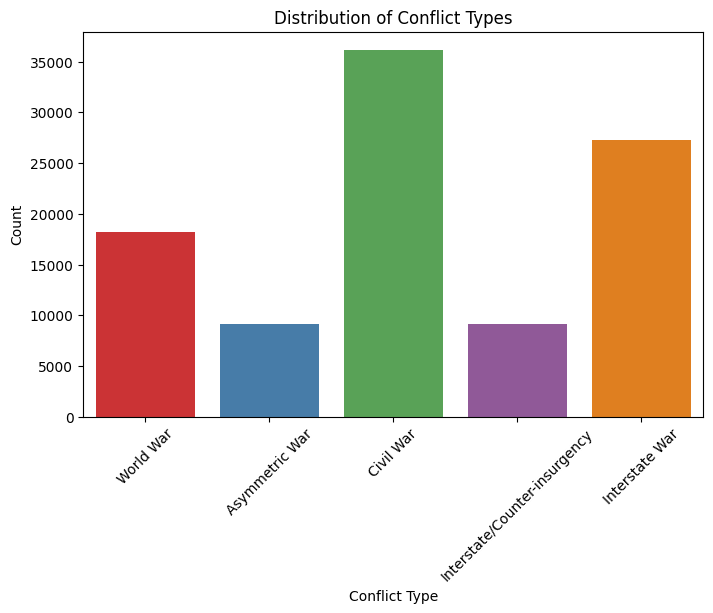

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Conflict_Type', data=df, palette='Set1')
plt.title("Distribution of Conflict Types")
plt.xlabel("Conflict Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

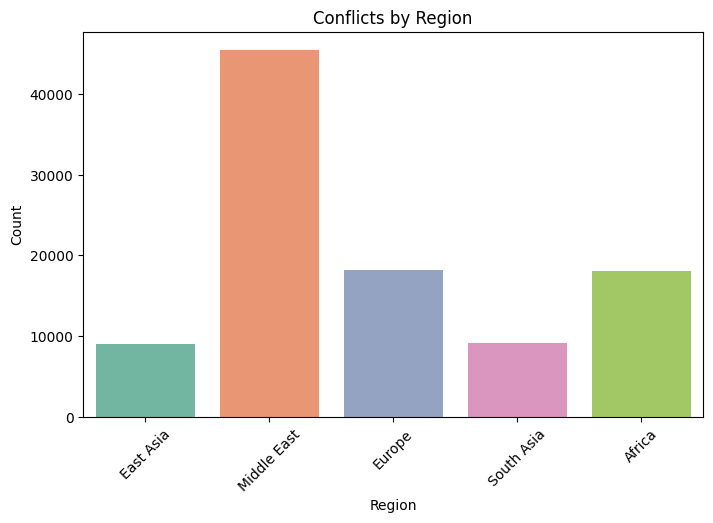

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='Region', data=df, palette='Set2')
plt.title("Conflicts by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

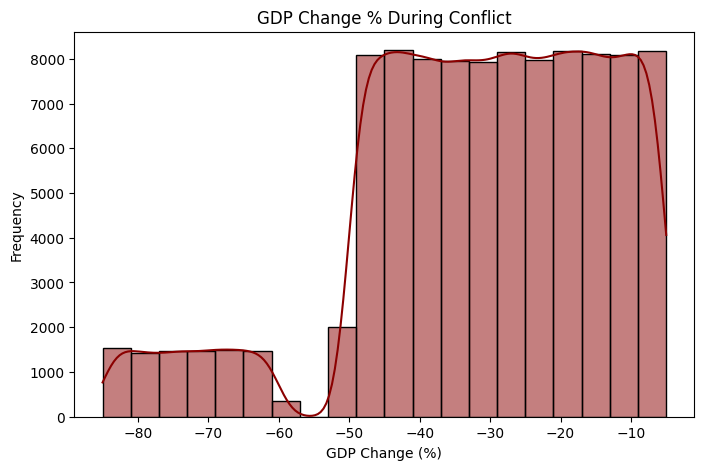

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['GDP_Change_%'], bins=20, kde=True, color='darkred')
plt.title("GDP Change % During Conflict")
plt.xlabel("GDP Change (%)")
plt.ylabel("Frequency")
plt.show()

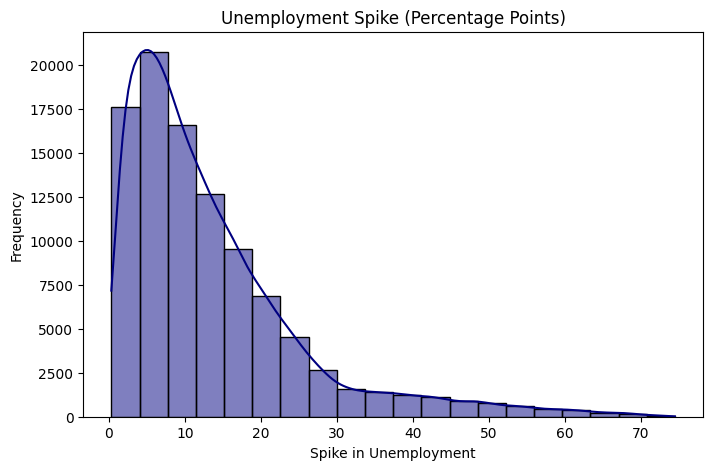

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Unemployment_Spike_Percentage_Points'],
             bins=20, kde=True, color='navy')
plt.title("Unemployment Spike (Percentage Points)")
plt.xlabel("Spike in Unemployment")
plt.ylabel("Frequency")
plt.show()

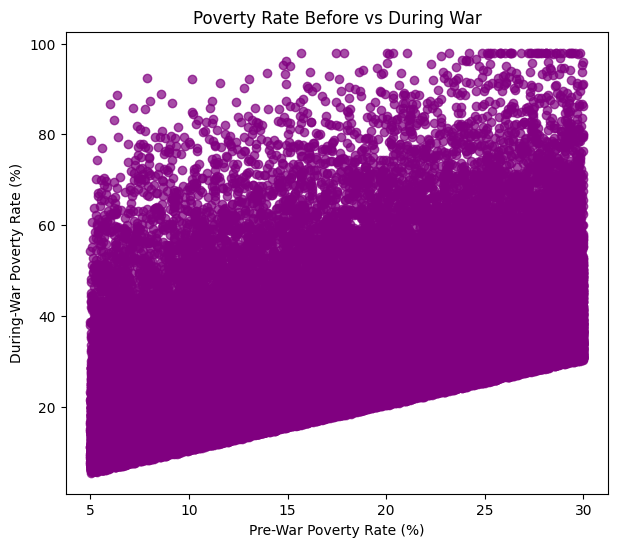

In [17]:
plt.figure(figsize=(7,6))

plt.scatter(df['Pre_War_Poverty_Rate_%'],
            df['During_War_Poverty_Rate_%'],
            color='purple', alpha=0.7)

plt.xlabel("Pre-War Poverty Rate (%)")
plt.ylabel("During-War Poverty Rate (%)")
plt.title("Poverty Rate Before vs During War")
plt.show()

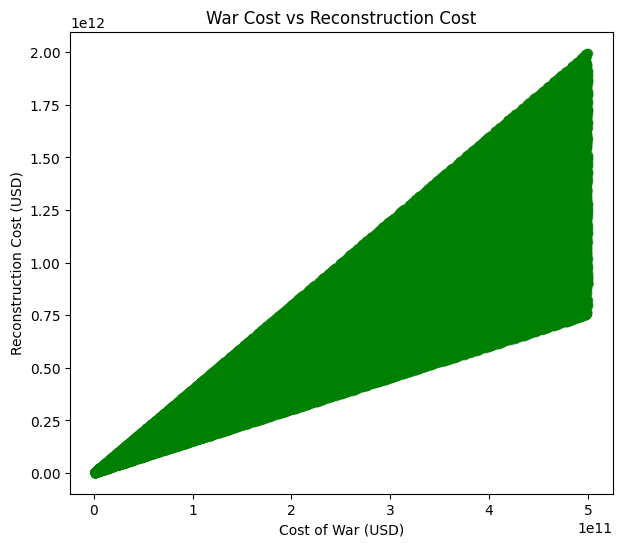

In [18]:
plt.figure(figsize=(7,6))

plt.scatter(df['Cost_of_War_USD'],
            df['Estimated_Reconstruction_Cost_USD'],
            color='green', alpha=0.6)

plt.xlabel("Cost of War (USD)")
plt.ylabel("Reconstruction Cost (USD)")
plt.title("War Cost vs Reconstruction Cost")
plt.show()

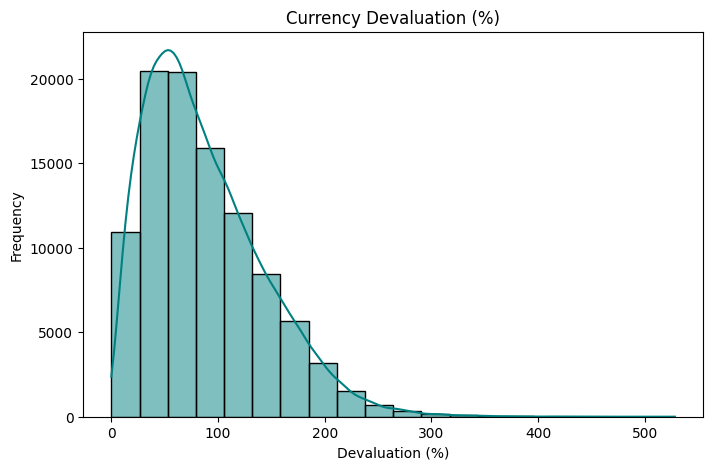

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Currency_Devaluation_%'], bins=20,
             kde=True, color='teal')
plt.title("Currency Devaluation (%)")
plt.xlabel("Devaluation (%)")
plt.ylabel("Frequency")
plt.show()

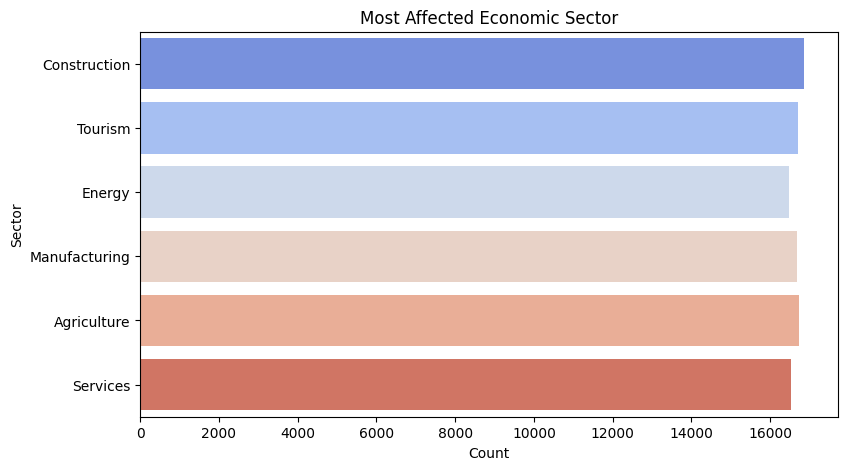

In [20]:
plt.figure(figsize=(9,5))
sns.countplot(y='Most_Affected_Sector',
              data=df,
              palette='coolwarm')

plt.title("Most Affected Economic Sector")
plt.xlabel("Count")
plt.ylabel("Sector")
plt.show()

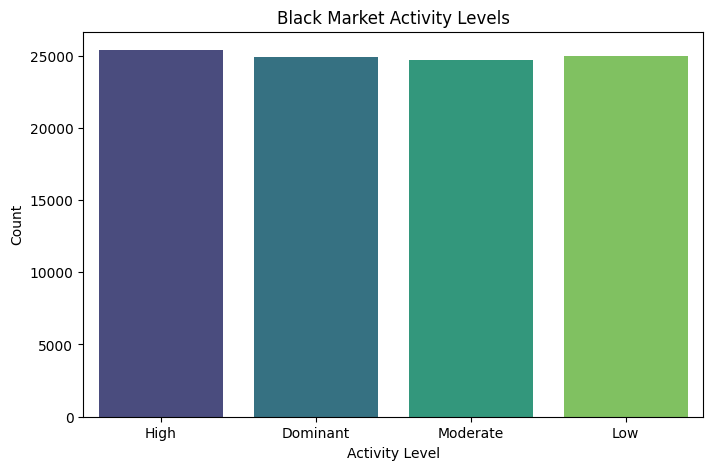

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(x='Black_Market_Activity_Level',
              data=df,
              palette='viridis')

plt.title("Black Market Activity Levels")
plt.xlabel("Activity Level")
plt.ylabel("Count")
plt.show()

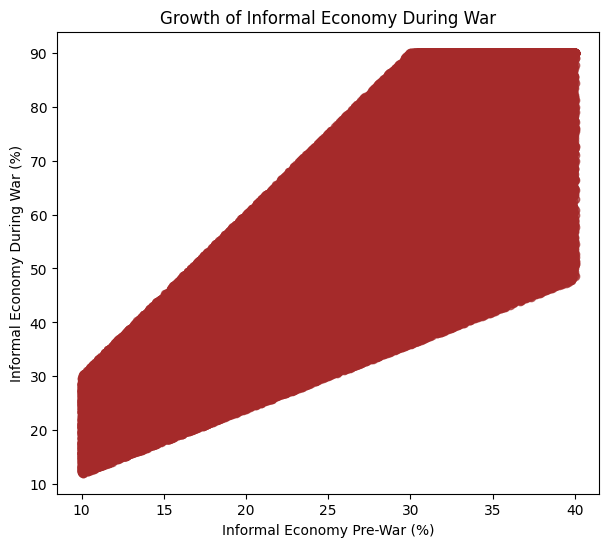

In [22]:
plt.figure(figsize=(7,6))

plt.scatter(df['Informal_Economy_Size_Pre_War_%'],
            df['Informal_Economy_Size_During_War_%'],
            color='brown', alpha=0.7)

plt.xlabel("Informal Economy Pre-War (%)")
plt.ylabel("Informal Economy During War (%)")
plt.title("Growth of Informal Economy During War")
plt.show()

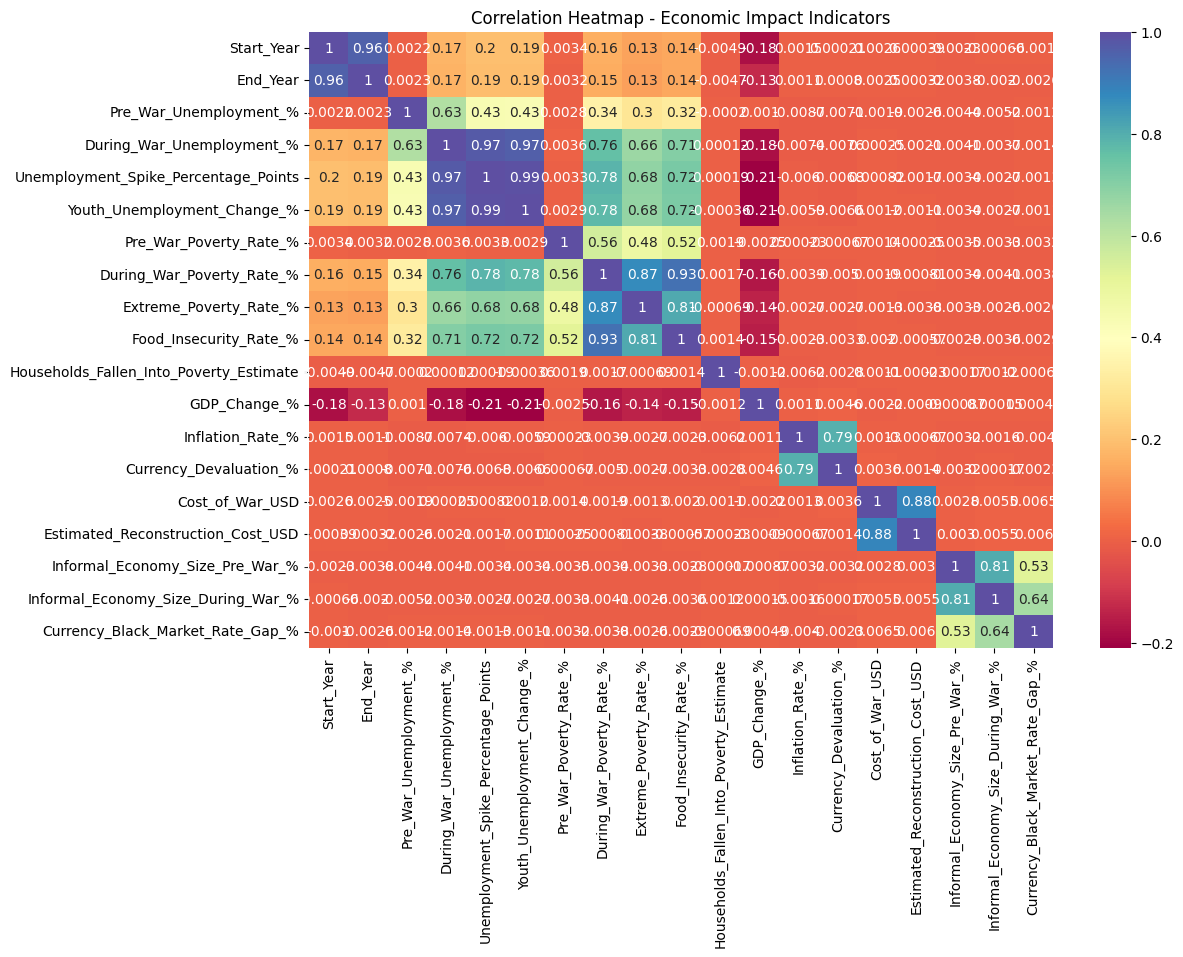

In [23]:
plt.figure(figsize=(12,8))

numeric_cols = df.select_dtypes(include=['float64','int64'])

sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='Spectral')

plt.title("Correlation Heatmap - Economic Impact Indicators")
plt.show()

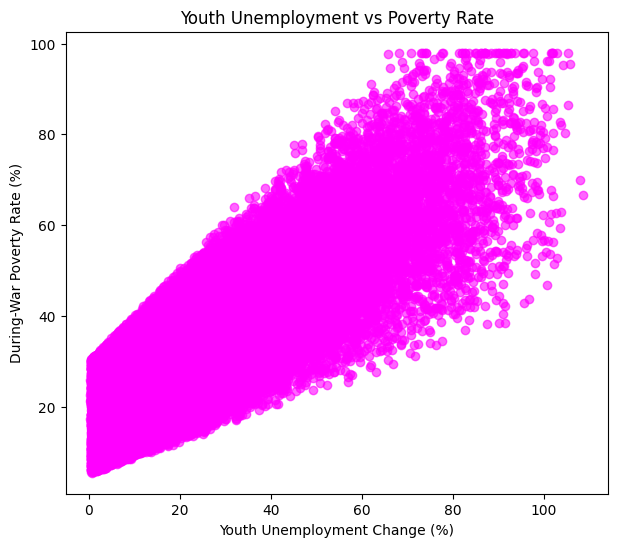

In [24]:
plt.figure(figsize=(7,6))

plt.scatter(df['Youth_Unemployment_Change_%'],
            df['During_War_Poverty_Rate_%'],
            color='magenta', alpha=0.6)

plt.xlabel("Youth Unemployment Change (%)")
plt.ylabel("During-War Poverty Rate (%)")
plt.title("Youth Unemployment vs Poverty Rate")
plt.show()

## Feature engg

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [26]:
# Convert target to binary if needed
df["War_Profiteering_Documented"] = df["War_Profiteering_Documented"].astype(str)

le_target = LabelEncoder()
df["War_Profiteering_Documented"] = le_target.fit_transform(
    df["War_Profiteering_Documented"]
)

In [27]:
df_model = df.drop(columns=["Conflict_Name"])

In [28]:
le = LabelEncoder()

for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = le.fit_transform(df_model[col])

In [29]:
X = df_model.drop("War_Profiteering_Documented", axis=1)
y = df_model["War_Profiteering_Documented"]

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model: Logistic Regression
Accuracy: 69.97%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6005
           1       0.70      1.00      0.82     13995

    accuracy                           0.70     20000
   macro avg       0.35      0.50      0.41     20000
weighted avg       0.49      0.70      0.58     20000



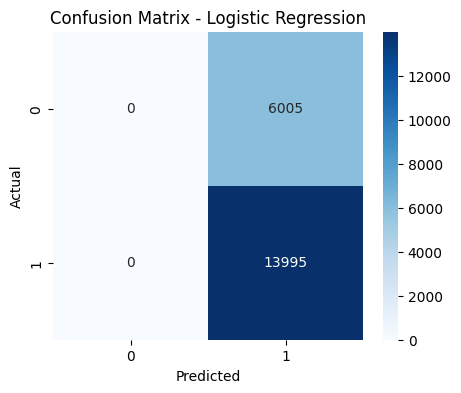

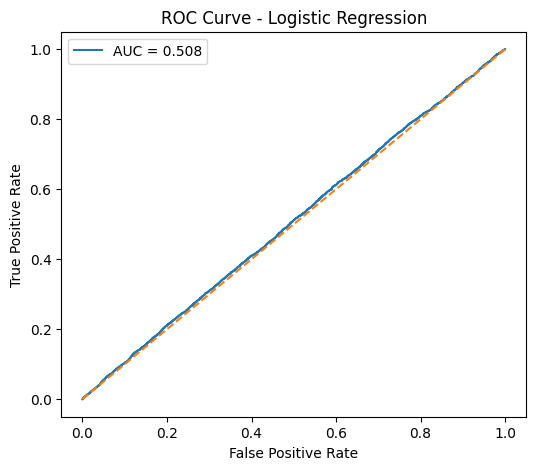

Model: Random Forest
Accuracy: 69.95%

Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.00      0.00      6005
           1       0.70      1.00      0.82     13995

    accuracy                           0.70     20000
   macro avg       0.52      0.50      0.41     20000
weighted avg       0.59      0.70      0.58     20000



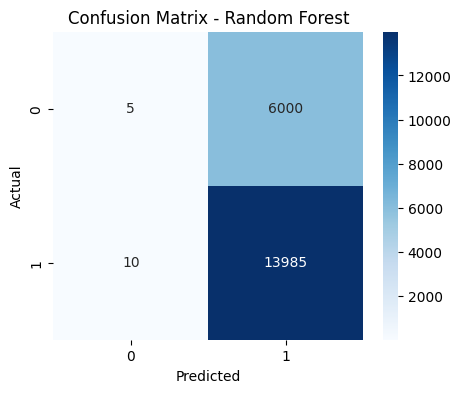

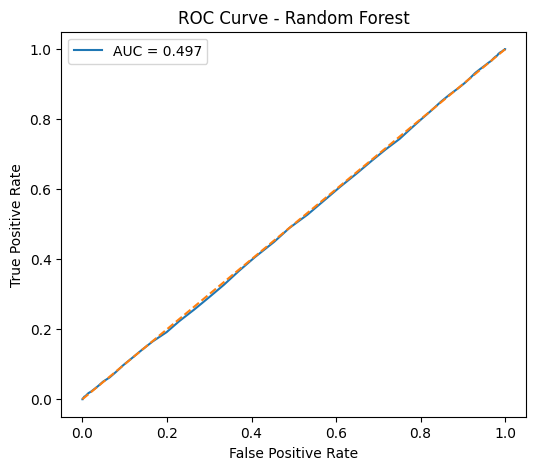

Model: Decision Tree
Accuracy: 57.29%

Classification Report:
              precision    recall  f1-score   support

           0       0.30      0.32      0.31      6005
           1       0.70      0.68      0.69     13995

    accuracy                           0.57     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.58      0.57      0.58     20000



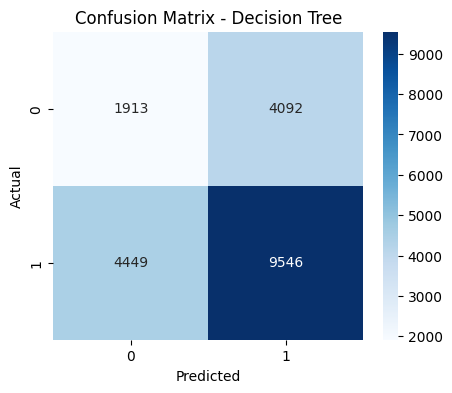

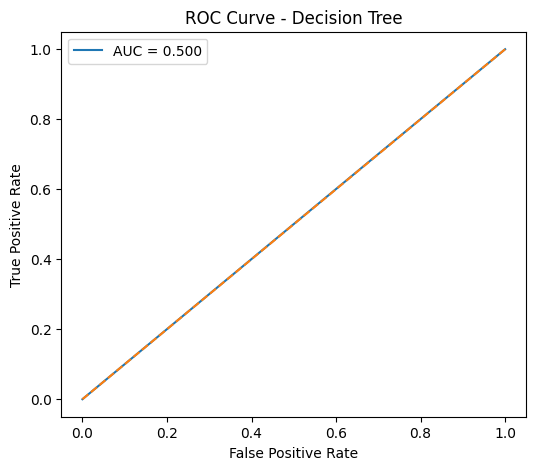

Model: SVM
Accuracy: 69.97%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6005
           1       0.70      1.00      0.82     13995

    accuracy                           0.70     20000
   macro avg       0.35      0.50      0.41     20000
weighted avg       0.49      0.70      0.58     20000



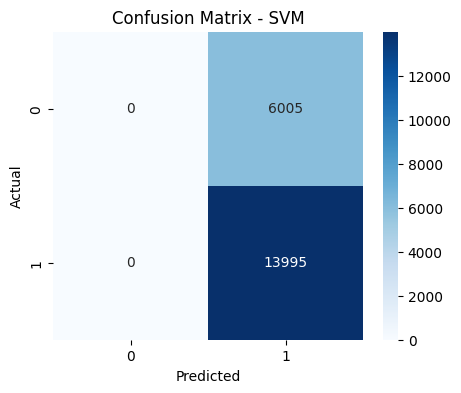

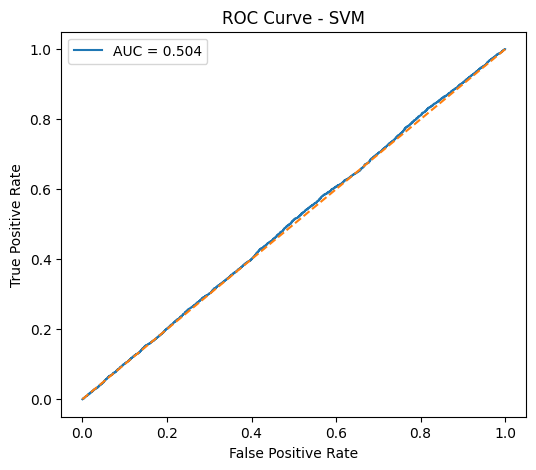

Model: Naive Bayes
Accuracy: 69.97%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      6005
           1       0.70      1.00      0.82     13995

    accuracy                           0.70     20000
   macro avg       0.35      0.50      0.41     20000
weighted avg       0.49      0.70      0.58     20000



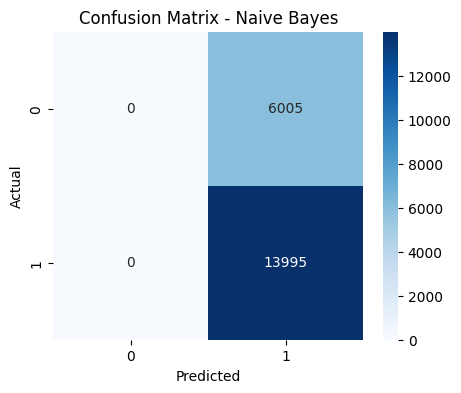

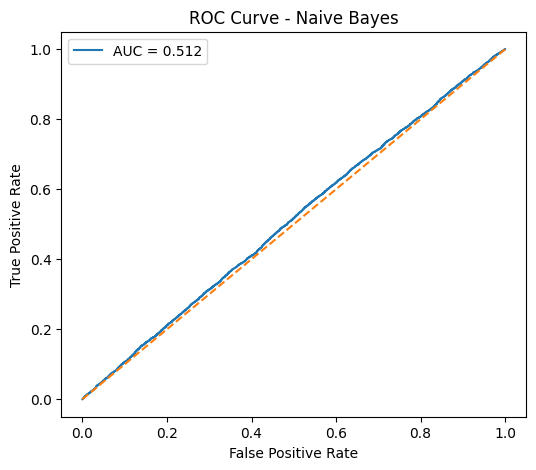

Model: KNN
Accuracy: 63.25%

Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.16      0.21      6005
           1       0.70      0.84      0.76     13995

    accuracy                           0.63     20000
   macro avg       0.50      0.50      0.48     20000
weighted avg       0.58      0.63      0.59     20000



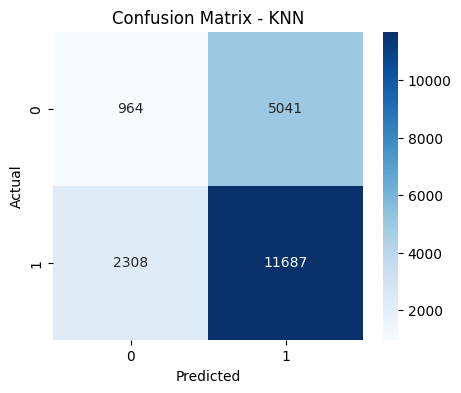

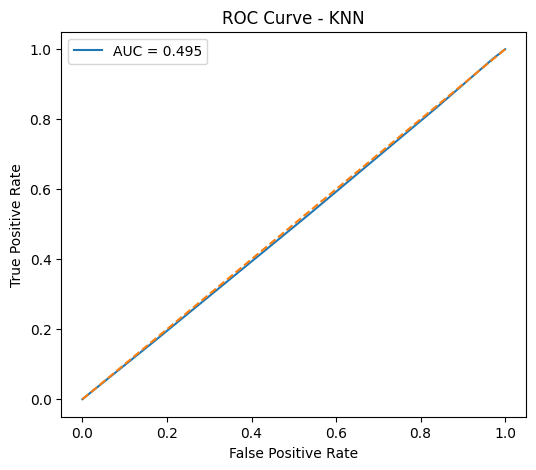

In [32]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred) * 100
    
    print("="*60)
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.2f}%")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # 🔹 Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # 🔹 ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC Curve - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

## Thank you..pls upvote!!!!!!!